In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
Median_Income=df["Income"].median()
print(Median_Income)

51381.5


In [6]:
# Handling Missing Values
df["Income"]=df["Income"].fillna(Median_Income)

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


### Feature Engineering

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [13]:
# New feature 1 - Age
df["Age"]=2026-df["Year_Birth"]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [15]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [16]:
# New Feature 2 - Customer Tensure
# we could have taken the present date and time but it will change every time we run the code
reference_date=df["Dt_Customer"].max() 
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [18]:
# New Feature 3 - Overall Spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntGoldProds"]+df["MntMeatProducts"]+df["MntSweetProducts"]+df["MntFishProducts"]

In [19]:
# New Feature 4 - Total Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [20]:
df["Education"]=df["Education"].replace({"Education":"Graduate","PhD":"Postgraduate","Master":"Postgraduate","2n Cycle":"Undergraduate","Basic":"Undergraduate"})
df["Education"].value_counts()

Education
Graduation       1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [21]:
df["Living_with"]=df["Marital_Status"].replace({"Married":"Partner","Together":"Partner","Single":"Alone","Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"})

In [22]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

### Drop Columns

In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='object')

In [24]:
df_cleaned=df.drop(columns=['ID','Year_Birth','Marital_Status','Kidhome',
       'Teenhome', 'Dt_Customer','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds'])

In [25]:
df_cleaned.shape

(2240, 15)

In [26]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


### Outliers

In [27]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_with'],
      dtype='object')

In [28]:
cols=["Income","Recency","Age","Total_Spending","Total_Children"]

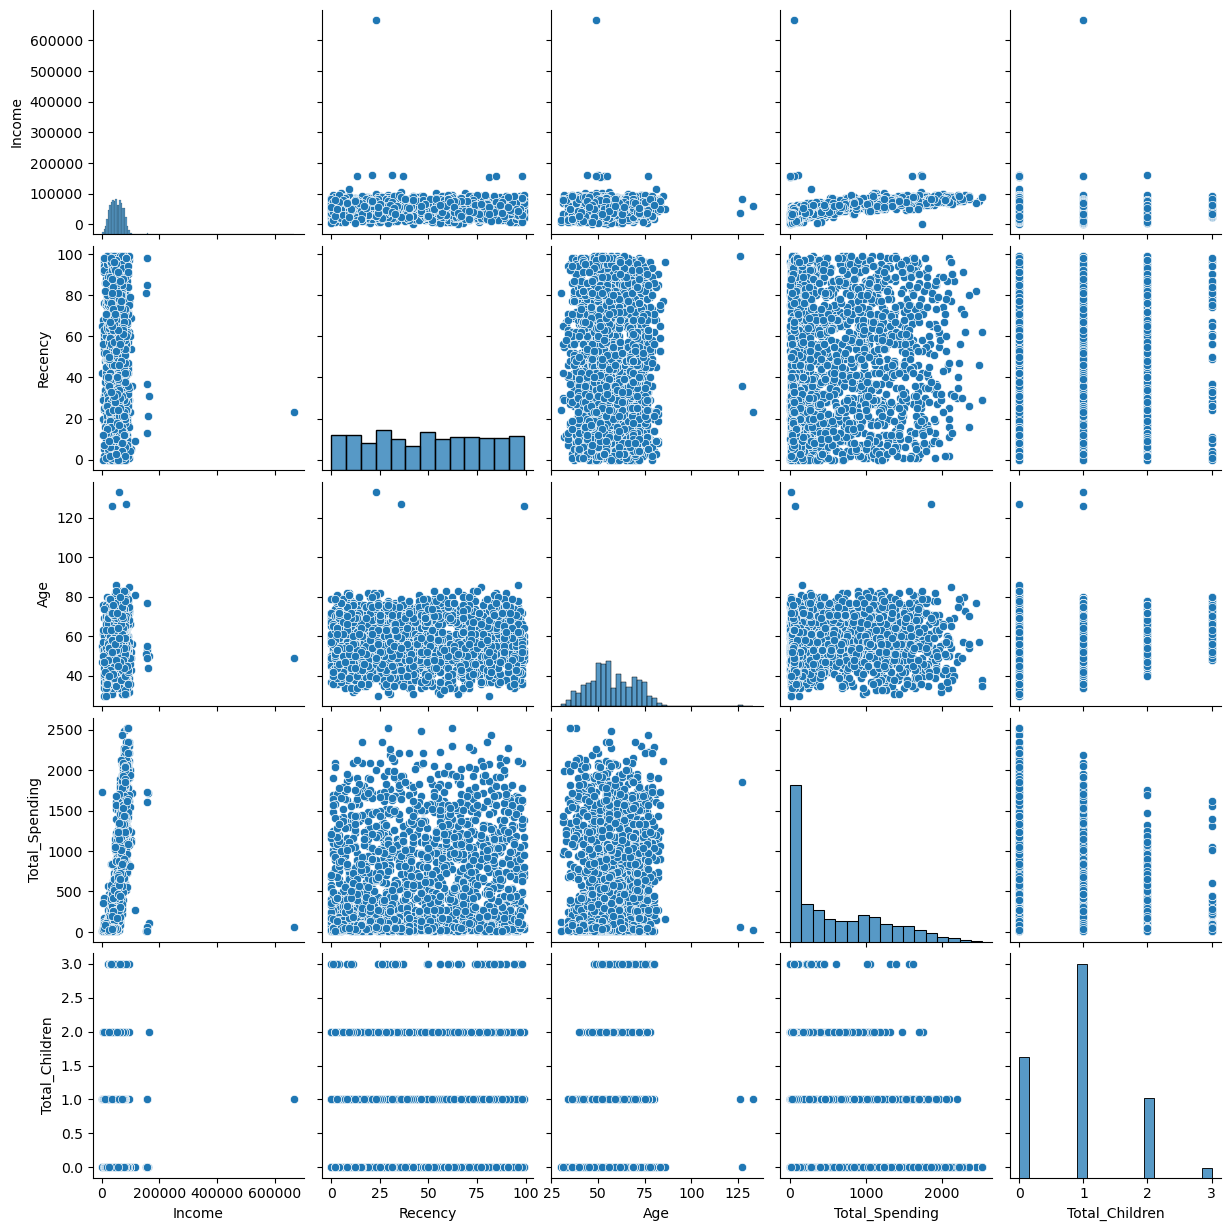

In [29]:
# relative plots of features using pairplots - they are like scatterplot of multiple features with eachother
sns.pairplot(df_cleaned[cols])

In [30]:
# Removing outliers
print("data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned=df_cleaned[ (df_cleaned["Income"]<600_000) ]
print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


### Heatmap

In [31]:
corr=df_cleaned.corr(numeric_only=True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

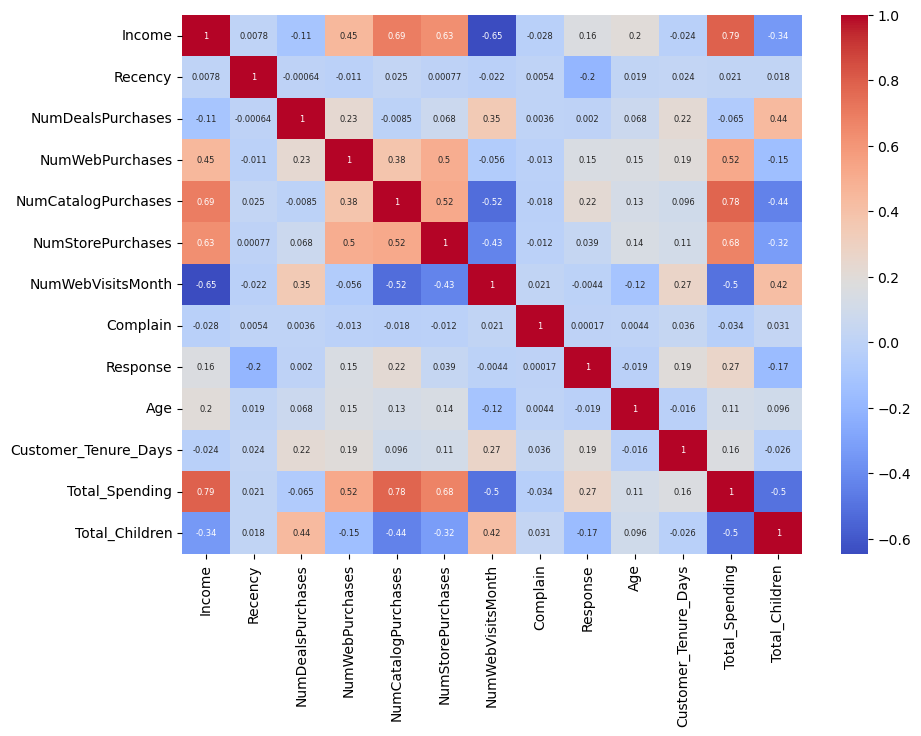

In [32]:
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,annot_kws={"size":6},cmap="coolwarm")

In [33]:
# Encoding
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler

In [34]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_with'],
      dtype='object')

In [35]:
cat_cols=['Education','Living_with']

In [36]:
ohe=OneHotEncoder() # no need to use drop_first=True in clustering
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index) # toarray()-sparse data into numpy array

In [37]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [38]:
df_encoded.shape

(2236, 18)

In [39]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [40]:
X=df_encoded

In [41]:
# Scaling
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [42]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

### Visualize

In [43]:
from sklearn.decomposition import PCA

In [44]:
# for visualizing our data we are converting it into 2D using PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

In [45]:
pca.explained_variance_ratio_   # every new feature capturing how vairance/eigen value

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

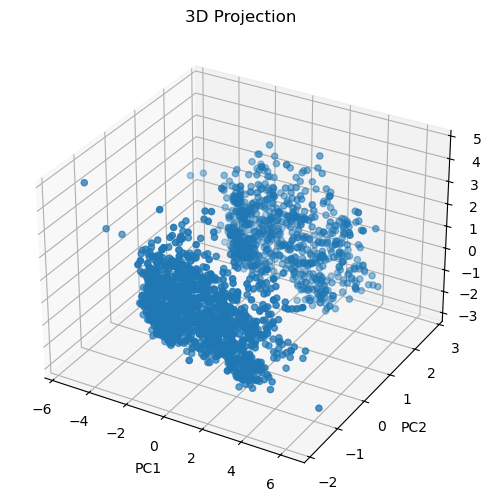

In [46]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

### Analyze K value 

In [47]:
!pip install kneed 

In [48]:
from sklearn.cluster import KMeans,AgglomerativeClustering
from kneed import KneeLocator

In [49]:
wcss=[]
for k in range(1,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

Text(0.5, 1.0, 'wcss vs k')

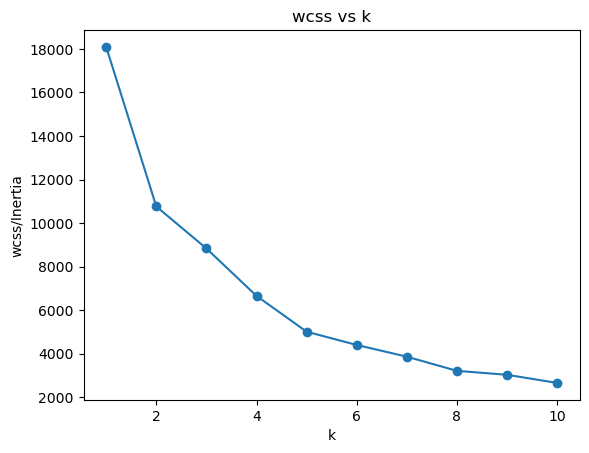

In [50]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss/Inertia")
plt.title("wcss vs k")

In [51]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.knee
print("Best value of k:",optimal_k)

Best value of k: 4


### Using Sihouette Score

In [52]:
from sklearn.metrics import silhouette_score

In [53]:
scores=[]
for k in range(2,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    labels=kmean.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Sihouette Score')

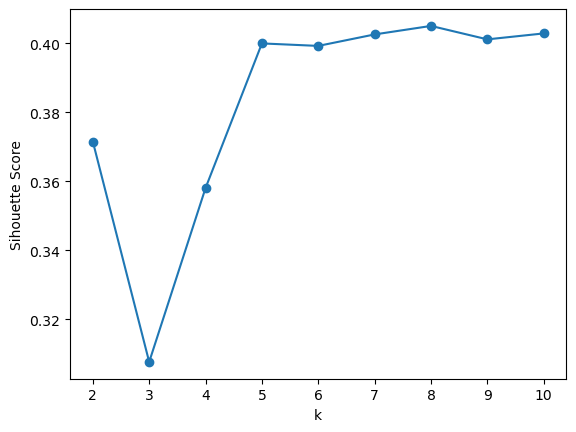

In [54]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("Sihouette Score")

### Clustering

In [55]:
# KMeans
kmean=KMeans(n_clusters=4,random_state=42)
labels_kmean=kmean.fit_predict(X_pca)

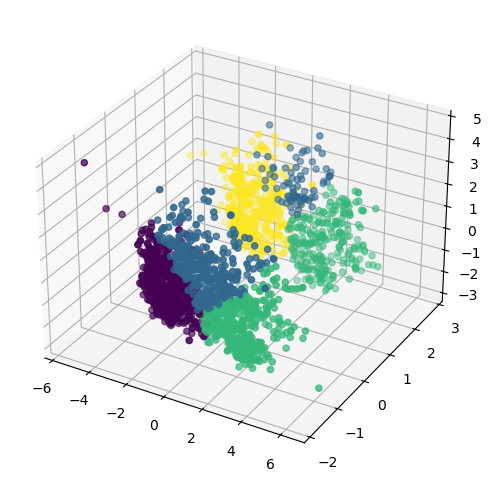

In [56]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmean)

In [57]:
# Agglomerative Clustering
agg_cls=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_cls.fit_predict(X_pca)

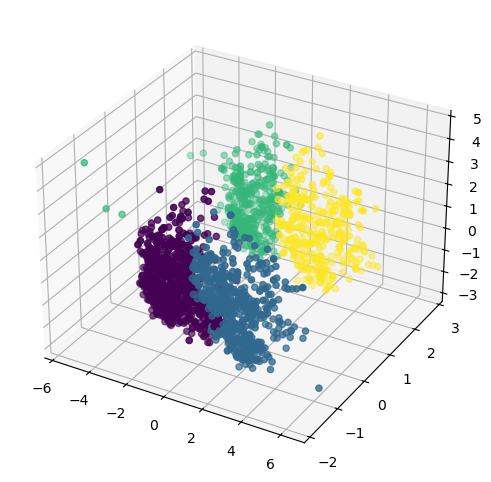

In [58]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

### Characterization of clusters

In [59]:
X["clusters"]=labels_agg

In [60]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

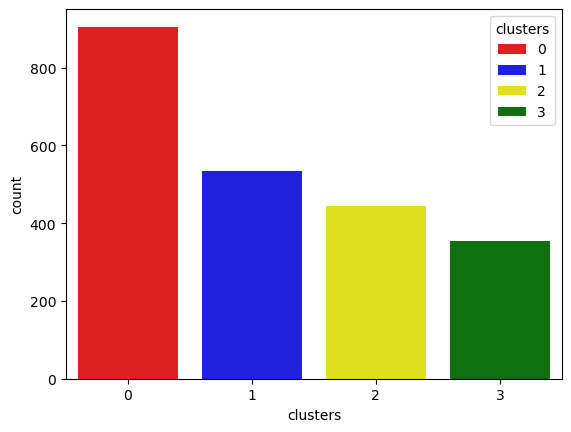

In [61]:
plt=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=plt,hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

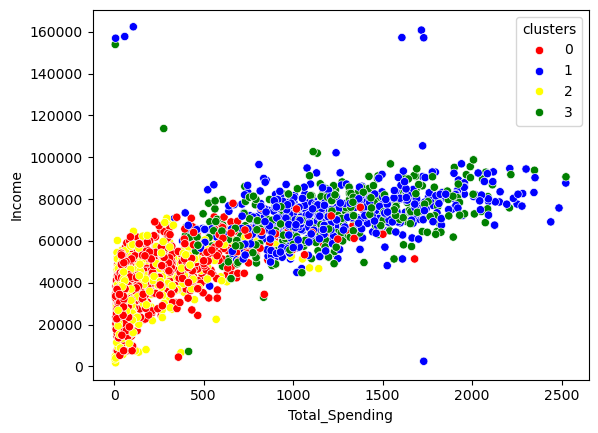

In [62]:
# Income vs Total Spending
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["clusters"],palette=plt)

In [63]:
#cluster 0:Red    ----> low/moderate spending  , low/moderate income
#cluster 1:Blue   ----> high spending          , high income
#cluster 2:Yellow ----> low spending           , low income
#cluster 3:Green  ----> high spending          , moderate/high income

In [64]:
X.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Education_Graduation', 'Education_Postgraduate',
       'Education_Undergraduate', 'Living_with_Alone', 'Living_with_Partner',
       'clusters'],
      dtype='object')

In [65]:
### Cluster Summary
cluster_summary=X.groupby("clusters").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
clusters,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


# Insights

## Business Insights

### Cluster 0 – Family Shoppers
- Low Income, Poor reponse, more children, have partners, more website visits, less store, web and catalog purchase
- Customers are price-sensitive and prefer value-for-money purchases.
- Discounts and family bundle offers are likely to improve engagement.

### Cluster 1 – Loyal Customers
- Very High Income, High age, average reponse, fewer children, alone, less website visits, high store, web and catalog purchase
- Customers show consistent purchasing behavior and moderate to high spending.
- Loyalty programs and personalized recommendations can improve retention.

### Cluster 2 – Digital Browsers
- Very Low Income, Average reponse, more children, have partners, more website visits, very less store, web and catalog purchase
- Customers are highly active online but spend relatively less.
- Sales and Heavy discounts and coupons can increase conversions.

### Cluster 3 – High-Value Customers
- High Income, slighlty high age, best reponse, fewer children, alone, less website visits, high store, web and catalog purchase 
- This segment contributes the highest revenue and spending.
- Premium services and exclusive offers should be prioritized for these customers.

